In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import pickle

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Model evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, f1_score

#Data Sampling
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

In [ ]:
df = pd.read_csv("/content/Rainfall.csv")
print(df.columns)
print(df.info())
print(df.head())
print(df['rainfall'].value_counts())
df = df.drop(columns = 'day')

df = df.rename(columns={"         winddirection": "winddirection", })

print(df.columns)
df['rainfall'] = df['rainfall'].replace({"yes": 1, "no": 0})

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  wi

/tmp/ipykernel_1667/954336752.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['rainfall'] = df['rainfall'].replace({"yes": 1, "no": 0})


# Collinearity EDA

In [ ]:
corr = df.corr(numeric_only=True)

print(corr["rainfall"].sort_values(ascending=False))

corr_matrix = df.drop(columns = 'rainfall').corr()
high_corr = []

for i in range(len(corr_matrix.columns)):
  for j in range(i+1, len(corr_matrix.columns)):
    if abs(corr_matrix.iloc[i,j])>0.8:
      high_corr.append((corr_matrix.columns[i],corr_matrix.columns[j],corr_matrix.iloc[i,j]))

print(high_corr)

df = df.drop(columns = ['maxtemp', 'mintemp', 'temparature'])

rainfall         1.000000
cloud            0.625766
humidity         0.489623
windspeed        0.154488
dewpoint         0.139916
mintemp         -0.007697
winddirection   -0.013214
temparature     -0.037360
pressure        -0.089275
maxtemp         -0.101003
sunshine        -0.552519
Name: rainfall, dtype: float64
[('pressure ', 'maxtemp', np.float64(-0.8290878807234762)), ('pressure ', 'temparature', np.float64(-0.8517804010690149)), ('pressure ', 'mintemp', np.float64(-0.8398511522791783)), ('pressure ', 'dewpoint', np.float64(-0.8602320025502757)), ('maxtemp', 'temparature', np.float64(0.986193355520295)), ('maxtemp', 'mintemp', np.float64(0.9615342242118082)), ('maxtemp', 'dewpoint', np.float64(0.8998289474865977)), ('temparature', 'mintemp', np.float64(0.9901870295773698)), ('temparature', 'dewpoint', np.float64(0.9368658828910246)), ('mintemp', 'dewpoint', np.float64(0.9445154753933875)), ('cloud ', 'sunshine', np.float64(-0.8483335835297101))]


# X and Y and Null value handling

In [ ]:
print(df.isna().sum())
df = df.replace({np.nan: 0})
print(df.isna().sum())

X = df.drop(columns = 'rainfall')
y = df['rainfall']
"""scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)"""

print(X.head())
print(X.shape)
print(y.head())
print(y.shape)

pressure         0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64
pressure         0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64
   pressure   dewpoint  humidity   cloud   sunshine  winddirection  windspeed
0     1025.9      13.1         72      49       9.3           80.0       26.3
1     1022.0      15.6         81      83       0.6           50.0       15.3
2     1019.7      18.4         95      91       0.0           40.0       14.2
3     1018.9      18.8         90      88       1.0           50.0       16.9
4     1015.9      19.9         95      81       0.0           40.0       13.7
(366, 7)
0    1
1    1
2    1
3    1
4    1
Name: rainfall, dtype: int64
(366,)


In [ ]:
X_train, X_temp ,y_train, y_temp = train_test_split(X, y, test_size = 0.4, random_state=42)
X_val, X_test ,y_val, y_test= train_test_split(X_temp, y_temp, test_size = 0.5, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(219, 7)
(219,)
(73, 7)
(73,)
(74, 7)
(74,)


# Model Selection

In [ ]:

models = [LogisticRegression(),
          DecisionTreeClassifier(),
          RandomForestClassifier(),
          XGBClassifier()]
for model in models:
  model_name = model.__class__.__name__
  scores = (cross_val_score(model, X_train, y_train, cv=5))
  print(scores)
  print(scores.mean())
  print(scores.std())
  print()

#We select logistic regression and random forest

[0.81818182 0.88636364 0.90909091 0.77272727 0.81395349]
0.8400634249471459
0.05020596387441006

[0.84090909 0.86363636 0.79545455 0.72727273 0.69767442]
0.7849894291754758
0.0638388538066678

[0.81818182 0.88636364 0.88636364 0.79545455 0.8372093 ]
0.8447145877378436
0.03648603962627976

[0.84090909 0.81818182 0.86363636 0.65909091 0.74418605]
0.785200845665962
0.07473849539304321



In [ ]:
model1 = RandomForestClassifier()
model1.fit(X_train, y_train)

y_train_pred1 = model1.predict(X_train)
y_val_pred1 = model1.predict(X_val)
y_test_pred1 = model1.predict(X_test)

print("Random Forest")
print(f"Accuracy of Train: {accuracy_score(y_train, y_train_pred1)}")
print(f"Accuracy of Val: {accuracy_score(y_val, y_val_pred1)}")
print(f"Accuracy of Test: {accuracy_score(y_test, y_test_pred1)}")
print("Classification Report", classification_report(y_val, y_val_pred1))
print("Confusion Matrix", confusion_matrix(y_val, y_val_pred1))
print()


model2 = LogisticRegression()
model2.fit(X_train, y_train)

y_train_pred2 = model2.predict(X_train)
y_val_pred2 = model2.predict(X_val)
y_test_pred2 = model2.predict(X_test)

print("Logistic Regression")
print(f"Accuracy of Train: {accuracy_score(y_train, y_train_pred2)}")
print(f"Accuracy of Val: {accuracy_score(y_val, y_val_pred2)}")
print(f"Accuracy of Test: {accuracy_score(y_test, y_test_pred2)}")
print("Classification Report", classification_report(y_val, y_val_pred2))
print("Confusion Matrix", confusion_matrix(y_val, y_val_pred2))
print()

Random Forest
Accuracy of Train: 1.0
Accuracy of Val: 0.8082191780821918
Accuracy of Test: 0.7972972972972973
Classification Report               precision    recall  f1-score   support

           0       0.73      0.52      0.61        21
           1       0.83      0.92      0.87        52

    accuracy                           0.81        73
   macro avg       0.78      0.72      0.74        73
weighted avg       0.80      0.81      0.80        73

Confusion Matrix [[11 10]
 [ 4 48]]

Logistic Regression
Accuracy of Train: 0.8310502283105022
Accuracy of Val: 0.7808219178082192
Accuracy of Test: 0.8108108108108109
Classification Report               precision    recall  f1-score   support

           0       0.67      0.48      0.56        21
           1       0.81      0.90      0.85        52

    accuracy                           0.78        73
   macro avg       0.74      0.69      0.71        73
weighted avg       0.77      0.78      0.77        73

Confusion Matrix [[10 11

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Hyperparametric Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

results = []

for n_estimators in [50, 100, 200, 300]:
  for max_depth in [3, 5, 10, None]:
    for min_samples_leaf in [1, 3, 5, 10]:
      model = RandomForestClassifier(
          n_estimators=n_estimators,
          max_depth=max_depth,
          min_samples_leaf=min_samples_leaf,
          random_state=42)
      """model.fit(X_train, y_train)
      train_acc = accuracy_score(y_train, model.predict(X_train))
      val_acc = accuracy_score(y_val, model.predict(X_val))"""
      cv_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring ='f1')
      results.append({
          "n_estimators": n_estimators,
          "max_depth": max_depth,
          "min_samples_leaf": min_samples_leaf,
          "cv_f1_mean":cv_f1.mean(),
          "cv_f1_std": cv_f1.std()}),

results_df = pd.DataFrame(results)
print(results_df.sort_values("cv_f1_mean", ascending=False).head(20))


    n_estimators  max_depth  min_samples_leaf  cv_f1_mean  cv_f1_std
41           200       10.0                 3    0.895517   0.032305
45           200        NaN                 3    0.895517   0.032305
48           300        3.0                 1    0.893025   0.036181
33           200        3.0                 3    0.893025   0.036181
49           300        3.0                 3    0.893025   0.036181
53           300        5.0                 3    0.891902   0.028678
27           100       10.0                10    0.891233   0.037338
31           100        NaN                10    0.891233   0.037338
39           200        5.0                10    0.889580   0.026844
43           200       10.0                10    0.889580   0.026844
47           200        NaN                10    0.889580   0.026844
7             50        5.0                10    0.889057   0.042765
15            50        NaN                10    0.889057   0.042765
11            50       10.0       

In [ ]:


modelRF = RandomForestClassifier(n_estimators = 150, max_depth = 3, class_weight='balanced', min_samples_leaf = 5, min_samples_split=20, random_state=42)
modelRF.fit(X_train, y_train)

y_train_predRF = modelRF.predict(X_train)
y_val_predRF = modelRF.predict(X_val)
y_test_predRF = modelRF.predict(X_test)

print("Random Forest")
print(f"Accuracy of Train: {accuracy_score(y_train, y_train_predRF)}")
print(f"Accuracy of Val: {accuracy_score(y_val, y_val_predRF)}")
print(f"Accuracy of Test: {accuracy_score(y_test, y_test_predRF)}")
print("Classification Report", classification_report(y_val, y_val_predRF))
print("Confusion Matrix", confusion_matrix(y_val, y_val_predRF))
print()

Random Forest
Accuracy of Train: 0.8538812785388128
Accuracy of Val: 0.7808219178082192
Accuracy of Test: 0.8108108108108109
Classification Report               precision    recall  f1-score   support

           0       0.63      0.57      0.60        21
           1       0.83      0.87      0.85        52

    accuracy                           0.78        73
   macro avg       0.73      0.72      0.72        73
weighted avg       0.78      0.78      0.78        73

Confusion Matrix [[12  9]
 [ 7 45]]



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Logistic Regression Model Tuning

In [ ]:
results = []
for C in [0.001,0.01,0.1,1,10,100]:
  model = LogisticRegression(C=C, max_iter=1000, random_state=42)
  model.fit(X_train, y_train)
  train_acc = accuracy_score(y_train, model.predict(X_train))
  val_acc = accuracy_score(y_val, model.predict(X_val))
  test_acc = accuracy_score(y_test, model.predict(X_test))
  cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring="f1")
  results.append({
      "C": C,
      "TrainAcc": train_acc,
      "ValAcc": val_acc,
      "TestAcc": test_acc,
      "cv_f1_mean": cv_score.mean(),
      "cv_f1_std": cv_score.std(),
  })

results_df = pd.DataFrame(results)
print(results_df.sort_values("cv_f1_mean", ascending=False))

#Best one: C = 10

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist

         C  TrainAcc    ValAcc   TestAcc  cv_f1_mean  cv_f1_std
4   10.000  0.840183  0.780822  0.810811    0.885722   0.036224
3    1.000  0.831050  0.780822  0.810811    0.885722   0.036224
5  100.000  0.840183  0.780822  0.810811    0.885722   0.036224
1    0.010  0.821918  0.808219  0.797297    0.879468   0.010034
2    0.100  0.835616  0.780822  0.797297    0.878506   0.036598
0    0.001  0.671233  0.712329  0.675676    0.803244   0.007376


In [ ]:
modelLR = LogisticRegression(C=10, max_iter=1000, random_state=42)
modelLR.fit(X_train, y_train)

LogisticRegression(C=10, max_iter=1000, random_state=42)

# Save and Load Model and data

In [ ]:
modelsF = [modelLR, modelRF]
with open("models.pkl", "wb") as f:
  pickle.dump(modelsF, f)

with open("models.pkl", "rb") as f:
  modelData = pickle.load(f)

#Predicting:
predX = scaler.transform(X.iloc[[44]])
print(modelData[0].predict(predX))
print(modelData[1].predict(predX))

[1]
[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Visualizations

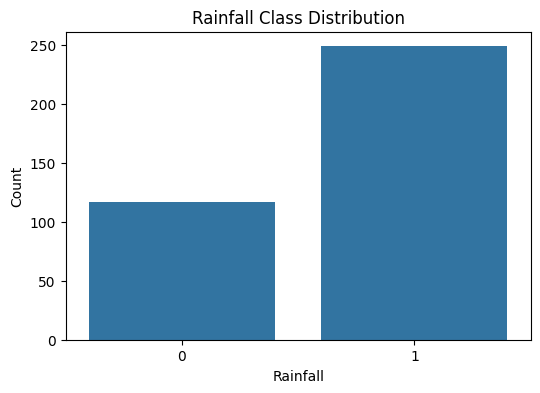

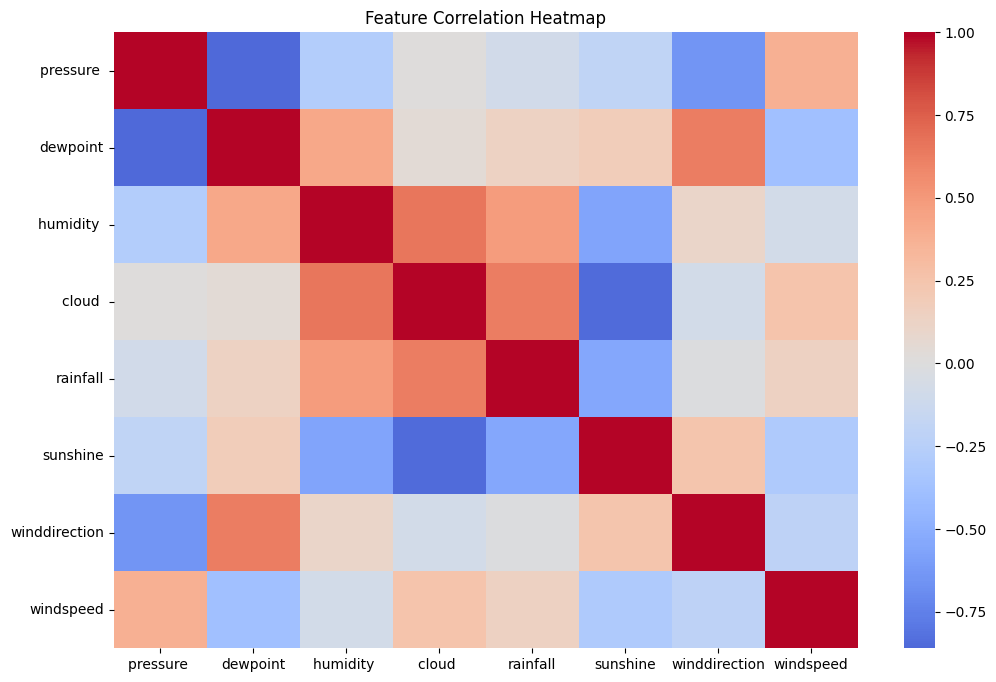

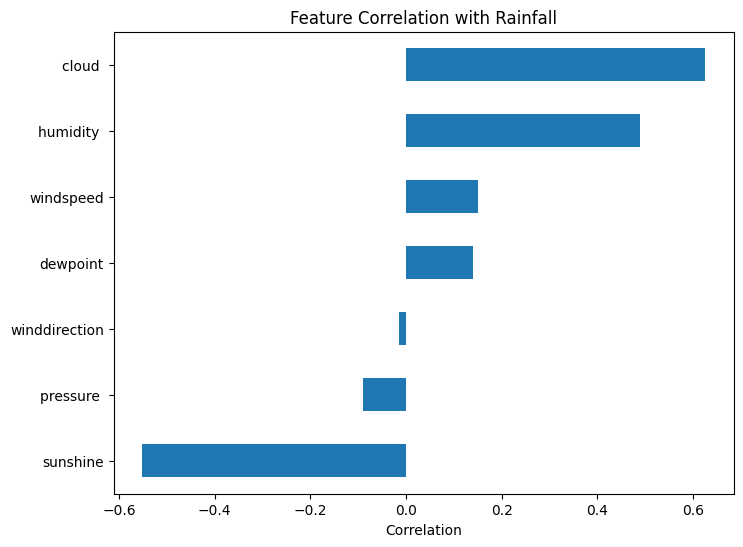

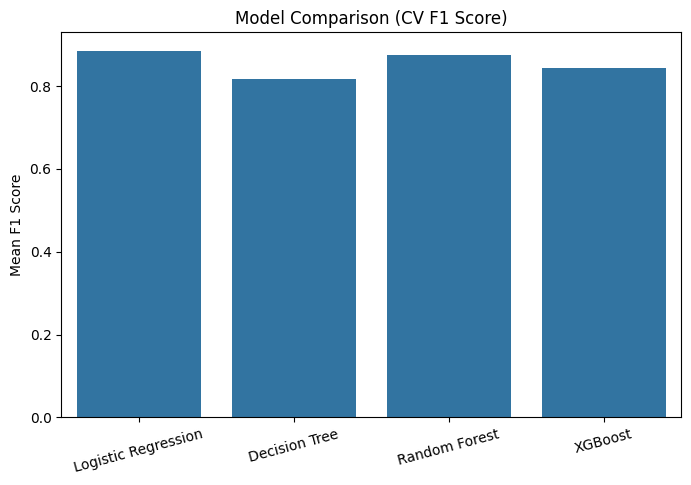

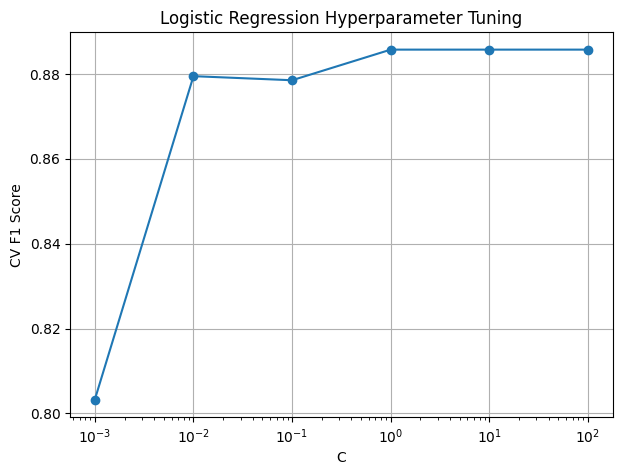

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


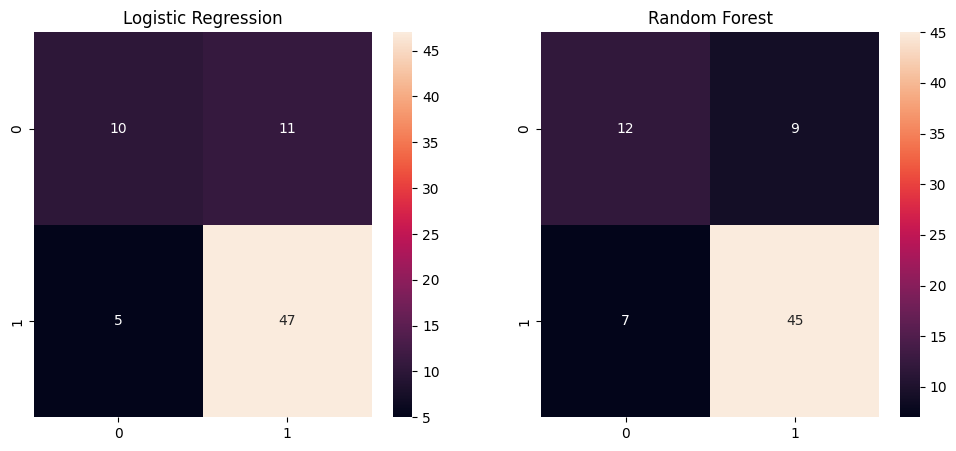

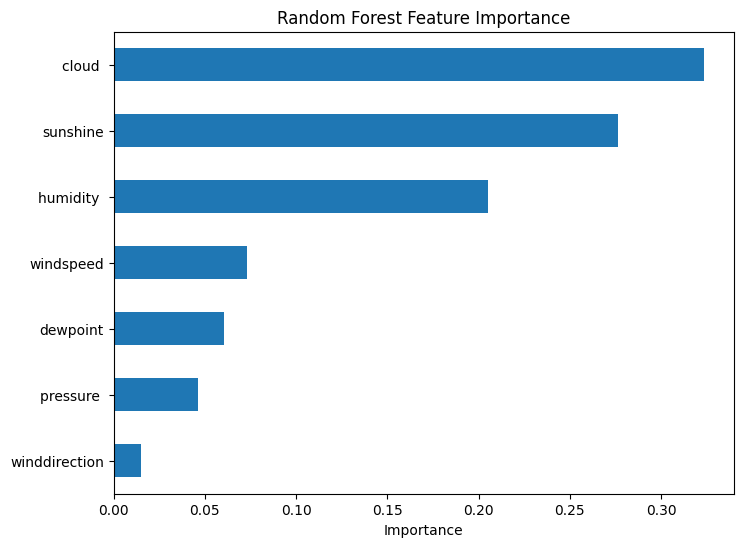

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


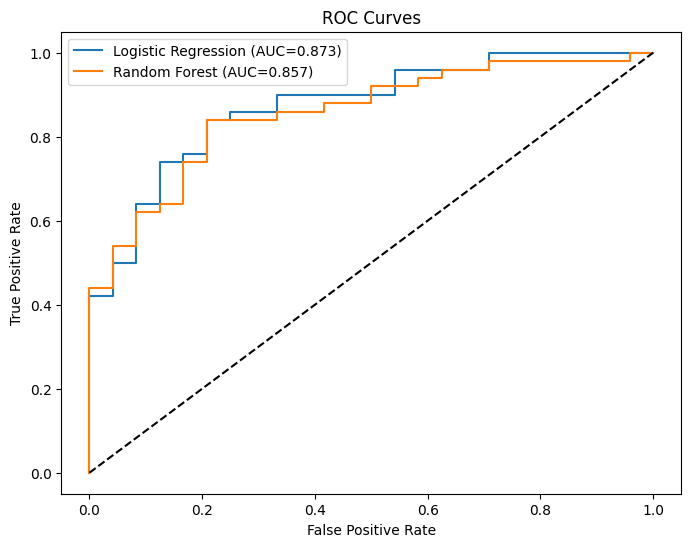

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


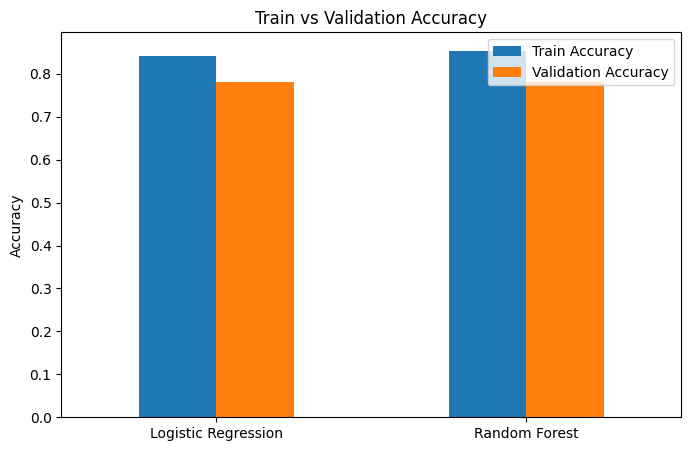

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score
)

# =====================================================
# 1. Rainfall Class Distribution
# =====================================================

plt.figure(figsize=(6,4))
sns.countplot(x=df["rainfall"])
plt.title("Rainfall Class Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Count")
plt.show()


# =====================================================
# 2. Correlation Heatmap
# =====================================================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            cmap="coolwarm",
            center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


# =====================================================
# 4. Model Comparison (Cross Validation)
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

model_names = []
f1_scores = []

for name, model in models.items():
    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()

    model_names.append(name)
    f1_scores.append(score)

plt.figure(figsize=(8,5))
sns.barplot(x=model_names, y=f1_scores)
plt.title("Model Comparison (CV F1 Score)")
plt.ylabel("Mean F1 Score")
plt.xticks(rotation=15)
plt.show()


# =====================================================
# 5. Random Forest Hyperparameter Heatmap
# =====================================================

# rf_results_df should contain:
# n_estimators
# max_depth
# cv_f1_mean

if "rf_results_df" in globals():

    heatmap_data = rf_results_df.pivot_table(
        values="cv_f1_mean",
        index="max_depth",
        columns="n_estimators"
    )

    plt.figure(figsize=(10,6))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap="viridis"
    )
    plt.title("Random Forest Hyperparameter Tuning")
    plt.show()


# =====================================================
# 6. Logistic Regression C vs F1
# =====================================================

plt.figure(figsize=(7,5))
plt.plot(
    results_df["C"],
    results_df["cv_f1_mean"],
    marker="o"
)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("CV F1 Score")
plt.title("Logistic Regression Hyperparameter Tuning")
plt.grid(True)
plt.show()


# =====================================================
# 7. Confusion Matrices
# =====================================================

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_val, modelLR.predict(X_val)),
    annot=True,
    fmt="d",
    ax=ax[0]
)

ax[0].set_title("Logistic Regression")

sns.heatmap(
    confusion_matrix(y_val, modelRF.predict(X_val)),
    annot=True,
    fmt="d",
    ax=ax[1]
)

ax[1].set_title("Random Forest")

plt.show()


# =====================================================
# 8. Random Forest Feature Importance
# =====================================================

feature_importance = pd.Series(
    modelRF.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(8,6))
feature_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

# =====================================================
# 10. Train vs Validation Accuracy
# =====================================================

train_acc_lr = accuracy_score(
    y_train,
    modelLR.predict(X_train)
)

val_acc_lr = accuracy_score(
    y_val,
    modelLR.predict(X_val)
)

train_acc_rf = accuracy_score(
    y_train,
    modelRF.predict(X_train)
)

val_acc_rf = accuracy_score(
    y_val,
    modelRF.predict(X_val)
)

comparison = pd.DataFrame({
    "Train Accuracy":[train_acc_lr, train_acc_rf],
    "Validation Accuracy":[val_acc_lr, val_acc_rf]
},
index=["Logistic Regression","Random Forest"])

comparison.plot(kind="bar", figsize=(8,5))

plt.title("Train vs Validation Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()